In [133]:
# Cell 1: imports + reload
import importlib
import pandas as pd
import recording_report as rr

importlib.reload(rr)
pd.set_option("display.max_columns", 200)

#### Show available recordings

In [134]:
meta = rr.recording_metadata()
display(meta)

,recording_id,mat_file_path,animal,session_label,session_datetime,part_index,file_size_bytes,n_trials
0,M046_2024_12_19_13_30_pyaldata_0,/Users/zosiasus/Documents/M046/M046_2024_12_19...,M046,2024_12_19_13_30,2024-12-19 13:30:00,0,1970048264,398
1,M046_2024_12_19_13_30_pyaldata_1,/Users/zosiasus/Documents/M046/M046_2024_12_19...,M046,2024_12_19_13_30,2024-12-19 13:30:00,1,1877218192,398


#### Choose recording

In [69]:
recording_id = "M046_2024_12_19_13_30_pyaldata_0"

### Summary report

In [70]:
summary = rr.build_recording_report_table(recording_id, include_all=True)
display(summary)

,recording_id,brain_region,n_units,mean_spikes,median_spikes,std_spikes,zero_fraction,animal,session_label,part_index,n_trials
0,M046_2024_12_19_13_30_pyaldata_0,CP,455,9.630742,1.0,63.441589,0.443332,M046,2024_12_19_13_30,0,398
1,M046_2024_12_19_13_30_pyaldata_0,MOp,281,15.574805,1.0,116.037365,0.468812,M046,2024_12_19_13_30,0,398
2,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,198,29.468238,3.0,202.965068,0.346886,M046,2024_12_19_13_30,0,398
3,M046_2024_12_19_13_30_pyaldata_0,Thal,184,88.791266,44.0,340.450974,0.047029,M046,2024_12_19_13_30,0,398
4,M046_2024_12_19_13_30_pyaldata_0,all,1118,27.666200,3.0,179.382646,0.367432,M046,2024_12_19_13_30,0,398


### See trial counts & trial types

In [80]:
trial_counts = rr.trial_counts(recording_id)
display(trial_counts)

trial_meta = rr._to_df(rr.Trial & {"recording_id": recording_id})[["trial_idx", "trial_type", "trial_length", "bin_size_sec"]]
display(
    trial_meta.groupby("trial_type", as_index=False)
    .agg(
        n_trials=("trial_idx", "count"),
        bin_size=("bin_size_sec", "mean"),
        mean_trial_length_bins=("trial_length", "mean"),
        mean_trial_duration_sec=("trial_length", lambda s: (s * trial_meta.loc[s.index, "bin_size_sec"]).mean()),
    )
)

,recording_id,n_trials_loaded
0,M046_2024_12_19_13_30_pyaldata_0,398


,trial_type,n_trials,bin_size,mean_trial_length_bins,mean_trial_duration_sec
0,free,1,0.01,30001.000000,300.010000
1,intertrial,199,0.01,319.090452,3.190905
2,trial,198,0.01,601.005051,6.010051


### Spike stats split by trial type

In [81]:
tot_type = rr.trial_totals(recording_id=recording_id, include_all=True, by_trial_type=True)
type_stats = (
    tot_type.groupby(["brain_region", "trial_type"], as_index=False)["trial_total_spikes"]
    .agg(mean_total="mean", std_total="std")
    .sort_values(["brain_region", "trial_type"])
)
display(type_stats)

,brain_region,trial_type,mean_total,std_total
0,CP,free,2.234690e+05,NaN
1,CP,intertrial,2.637749e+03,1541.969070
2,CP,trial,5.028535e+03,962.086304
3,MOp,free,2.523480e+05,NaN
4,MOp,intertrial,2.574990e+03,1416.273364
5,MOp,trial,4.934768e+03,701.455880
6,SSp_ll,free,3.429890e+05,NaN
7,SSp_ll,intertrial,3.403889e+03,1861.732398
8,SSp_ll,trial,6.575010e+03,827.071956
9,Thal,free,8.454770e+05,NaN


NaN for the std of the 'free' period as only 1 period exists

#### Spike rates (Hz) on account of different trial lengths

In [73]:
rates = rr.trial_rate_totals(recording_id=recording_id, include_all=True, by_trial_type=True)
display(rates.head())

rate_stats = (
    rates.groupby(["brain_region", "trial_type"], as_index=False)["spikes_per_sec"]
    .agg(mean_hz="mean", median_hz="median", std_hz="std")
    .sort_values(["brain_region", "trial_type"])
)
display(rate_stats)

,recording_id,brain_region,trial_idx,trial_total_spikes,trial_type,trial_length,bin_size_sec,trial_duration_sec,spikes_per_sec
0,M046_2024_12_19_13_30_pyaldata_0,CP,0,223469,free,30001,0.01,300.01,744.871838
1,M046_2024_12_19_13_30_pyaldata_0,CP,1,3659,intertrial,501,0.01,5.01,730.339321
2,M046_2024_12_19_13_30_pyaldata_0,CP,2,4775,trial,601,0.01,6.01,794.509151
3,M046_2024_12_19_13_30_pyaldata_0,CP,3,761,intertrial,101,0.01,1.01,753.465347
4,M046_2024_12_19_13_30_pyaldata_0,CP,4,5059,trial,601,0.01,6.01,841.763727


,brain_region,trial_type,mean_hz,median_hz,std_hz
0,CP,free,744.871838,744.871838,NaN
1,CP,intertrial,817.608943,808.383234,171.456701
2,CP,trial,836.688961,828.868552,160.086320
3,MOp,free,841.131962,841.131962,NaN
4,MOp,intertrial,804.798418,809.381238,124.628814
5,MOp,trial,821.085669,845.967131,116.713125
6,SSp_ll,free,1143.258558,1143.258558,NaN
7,SSp_ll,intertrial,1064.165982,1080.066445,156.498217
8,SSp_ll,trial,1094.001828,1116.139767,137.610406
9,Thal,free,2818.162728,2818.162728,NaN


NaN for the std of the 'free' period as only 1 period exists, and same mean and median for the same reason

## Plots

/Users/zosiasus/Documents/databases_practice/recording_report.py:352: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/Users/zosiasus/Documents/databases_practice/recording_report.py:359: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



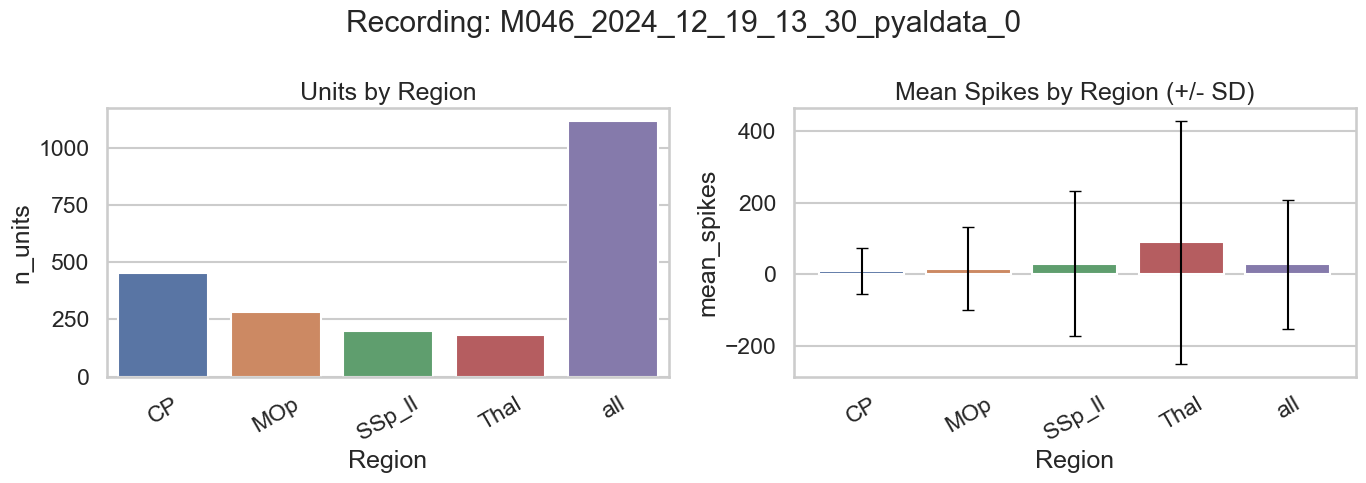

In [113]:
p_summary = rr.plot_summary_bars(recording_id, include_all=True, log_y=False)

#### Spikes recorded per trial (all trial types)

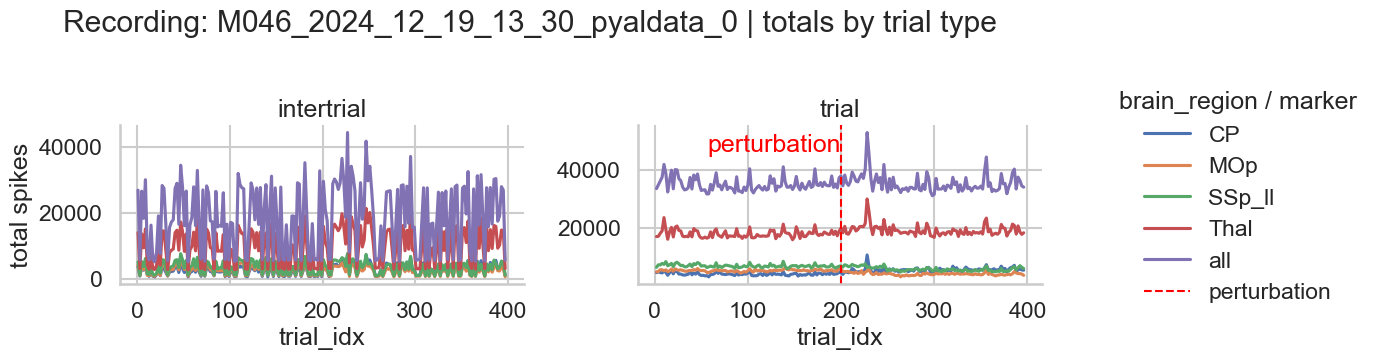

In [135]:
p_spike_per_type = rr.plot_trial_totals(recording_id=recording_id, include_all=True)

#### Activity rate (Hz) plot per unit

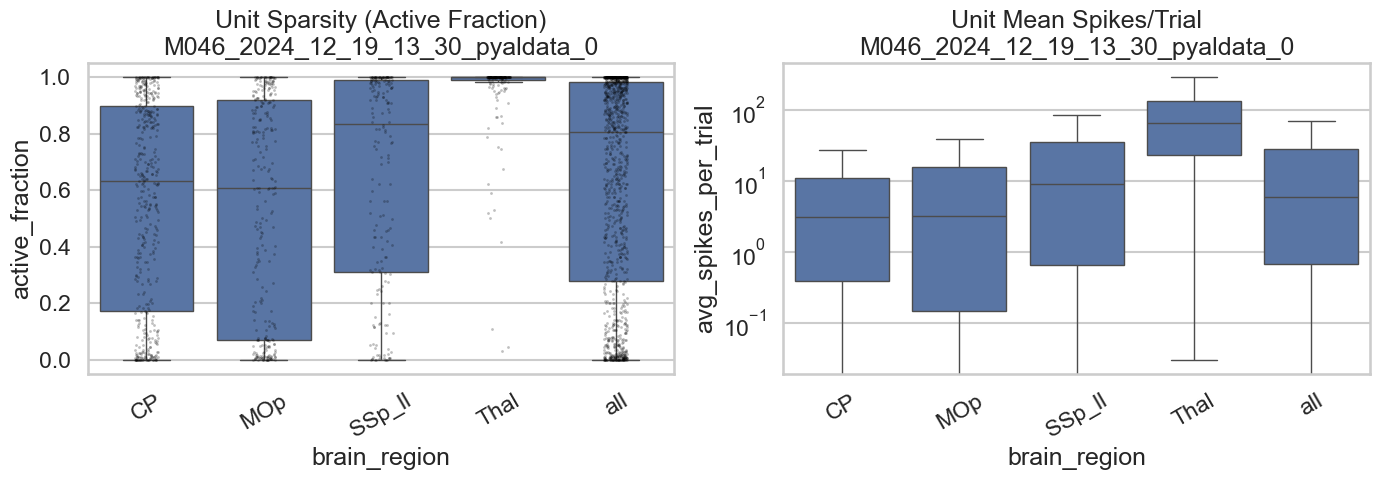

In [131]:
p_spike_rate = rr.plot_unit_sparsity_and_rate(recording_id)